# Sepsis Survival Prediction Using Decision Trees

**Code authored by**: Shawhin Talebi <br>
**Article link**: https://medium.com/towards-data-science/decision-trees-introduction-intuition-dac9592f4b7f <br>
**Data source**: 
- UCI: https://archive.ics.uci.edu/ml/datasets/Sepsis+survival+minimal+clinical+records
- Chicco, D., Jurman, G. Survival prediction of patients with sepsis from age, sex, and septic episode number alone. Sci Rep 10, 17156 (2020). https://doi.org/10.1038/s41598-020-73558-3

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

### Data prep

In [2]:
df = pd.read_csv('raw/s41598-020-73558-3_sepsis_survival_primary_cohort.csv')

In [3]:
df

,age_years,sex_0male_1female,episode_number,hospital_outcome_1alive_0dead
0,21,1,1,1
1,20,1,1,1
2,21,1,1,1
3,77,0,1,1
4,72,0,1,1
...,...,...,...,...
110199,0,0,1,1
110200,0,1,1,1
110201,70,1,1,1
110202,0,0,1,1


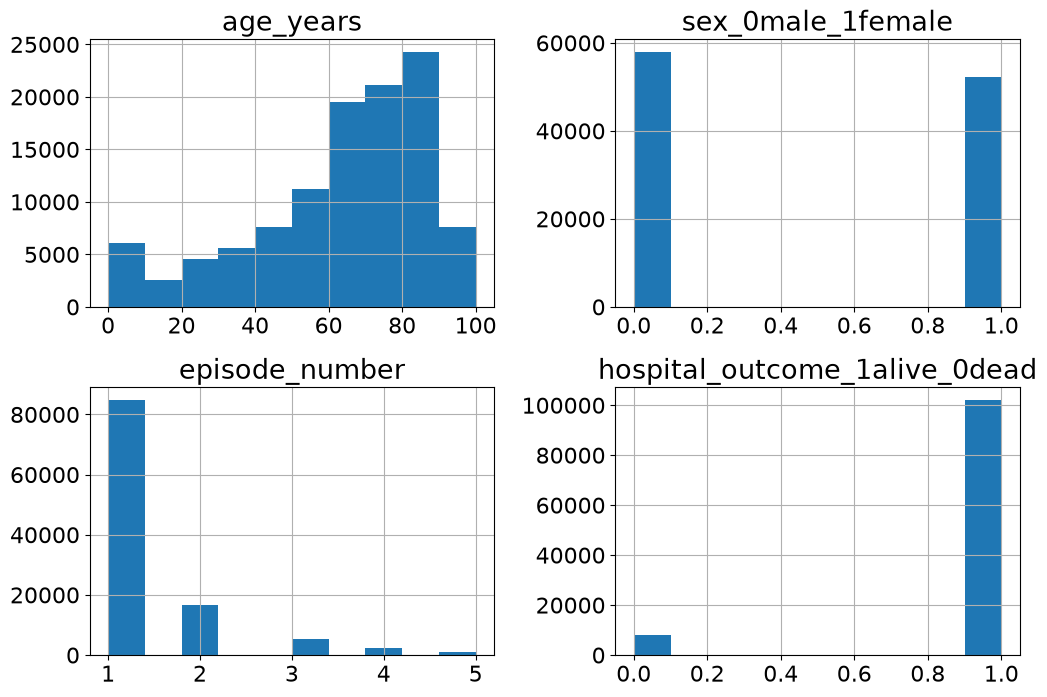

In [4]:
plt.rcParams.update({'font.size': 16})

df.hist(figsize=(12,8))
plt.savefig('visuals/raw_histograms.png',facecolor='white',bbox_inches="tight")

#### Balance data using SMOTE

In [5]:
# define predictor and target variable names
X_var_names = df.columns[:3]
y_var_name = df.columns[3]

# create predictor and target arrays
X = df[X_var_names]
y = df[y_var_name]

# NOTE: SMOTE is applied AFTER the train-test split (below), only on the
# training data. Applying it before the split leaks information from
# test patients into the synthetic training samples.

#### Train-test split

In [6]:
# split first on the original (imbalanced) data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# oversample minority class using SMOTE, fit only on the training data
X_train, y_train = SMOTE().fit_resample(X_train, y_train)

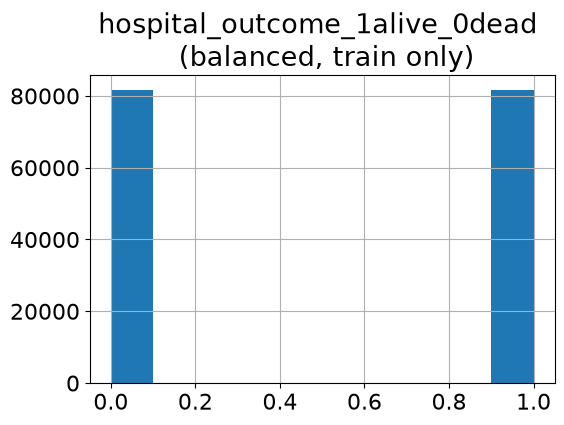

In [7]:
y_train.hist(figsize=(6,4))
plt.title('hospital_outcome_1alive_0dead \n (balanced, train only)')
plt.savefig('visuals/balanced_outcome_histogram_no_leakage.png',facecolor='white',bbox_inches="tight")

In [8]:
X_train.shape

(163456, 3)

In [9]:
X_test.shape

(22041, 3)

### Decision tree

In [10]:
# train model
clf = tree.DecisionTreeClassifier(random_state=0)
clf = clf.fit(X_train, y_train)

##### Display decision tree

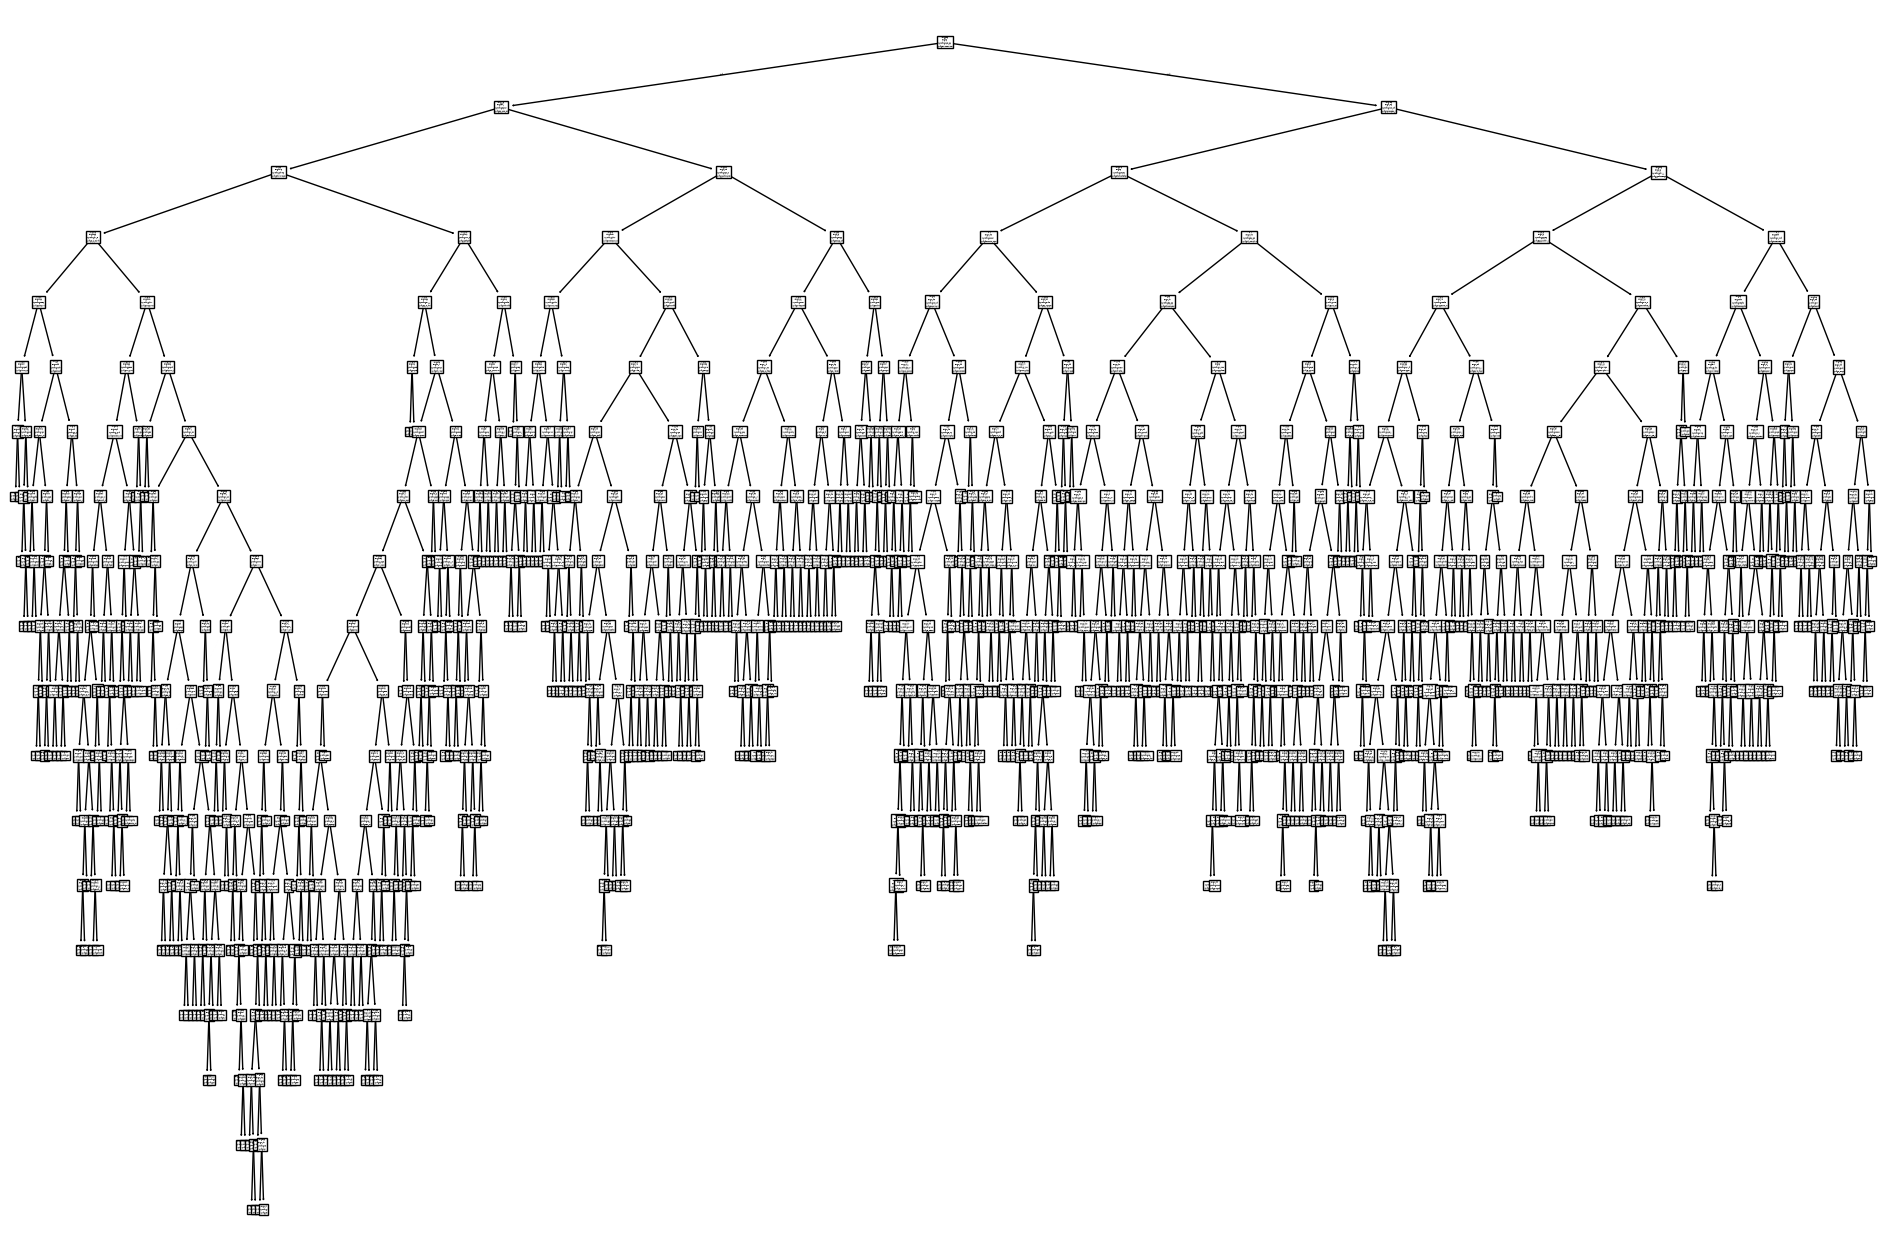

In [11]:
plt.figure(figsize=(24,16))

tree.plot_tree(clf)
plt.savefig('visuals/fully_grown_decision_tree.png',facecolor='white',bbox_inches="tight")
plt.show()

##### Evaluate performance

In [12]:
from sklearn.metrics import classification_report

def evaluateModel(clf, X, y):

    # confusion matrix (dead=0 first row/col, alive=1 second)
    y_pred = clf.predict(X)
    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    cm_disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['dead', 'alive'])
    cm_disp.plot()

    # clinically relevant class is "dead" (0), so pos_label=0
    print("Precision (dead) = " + str(np.round(precision_score(y, y_pred, pos_label=0),3)))
    print("Recall (dead) = " + str(np.round(recall_score(y, y_pred, pos_label=0),3)))
    print("F1 (dead) = " + str(np.round(f1_score(y, y_pred, pos_label=0),3)))
    print()
    print(classification_report(y, y_pred, target_names=['dead', 'alive']))

Precision (dead) = 0.626
Recall (dead) = 0.824
F1 (dead) = 0.712

              precision    recall  f1-score   support

        dead       0.63      0.82      0.71     81728
       alive       0.74      0.51      0.60     81728

    accuracy                           0.67    163456
   macro avg       0.68      0.67      0.66    163456
weighted avg       0.68      0.67      0.66    163456



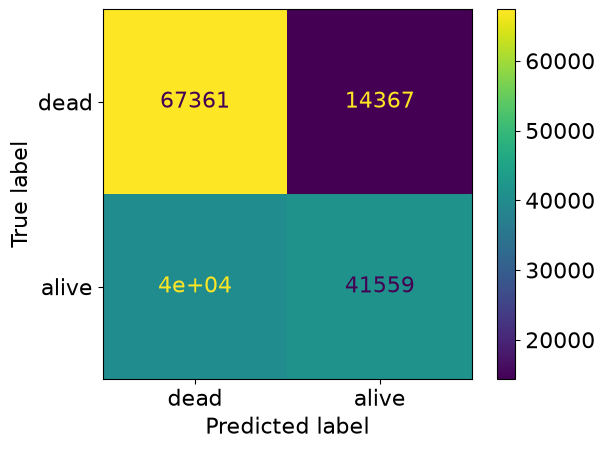

In [13]:
evaluateModel(clf, X_train, y_train)
plt.savefig('visuals/fully_grown_decision_tree_training_performance.png',facecolor='white',bbox_inches="tight")

Precision (dead) = 0.113
Recall (dead) = 0.769
F1 (dead) = 0.197

              precision    recall  f1-score   support

        dead       0.11      0.77      0.20      1670
       alive       0.96      0.51      0.66     20371

    accuracy                           0.53     22041
   macro avg       0.54      0.64      0.43     22041
weighted avg       0.90      0.53      0.63     22041



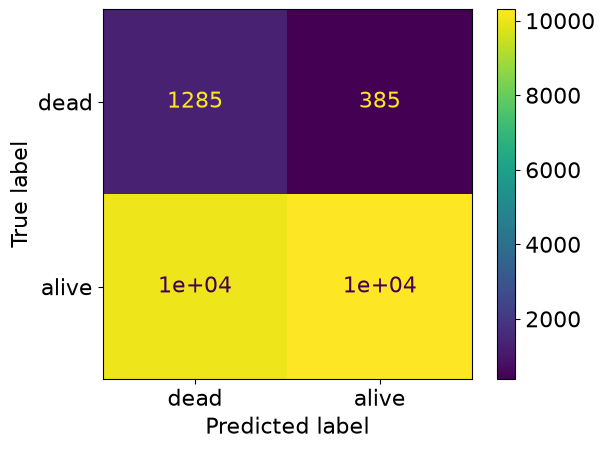

In [14]:
evaluateModel(clf, X_test, y_test)
plt.savefig('visuals/fully_grown_decision_tree_testing_performance.png',facecolor='white',bbox_inches="tight")

### Hyperparameter tuning

In [15]:
# train model
clf_tuned = tree.DecisionTreeClassifier(random_state=0, max_depth=3) # set max depth to 3
clf_tuned = clf_tuned.fit(X_train, y_train)

##### Display decision tree

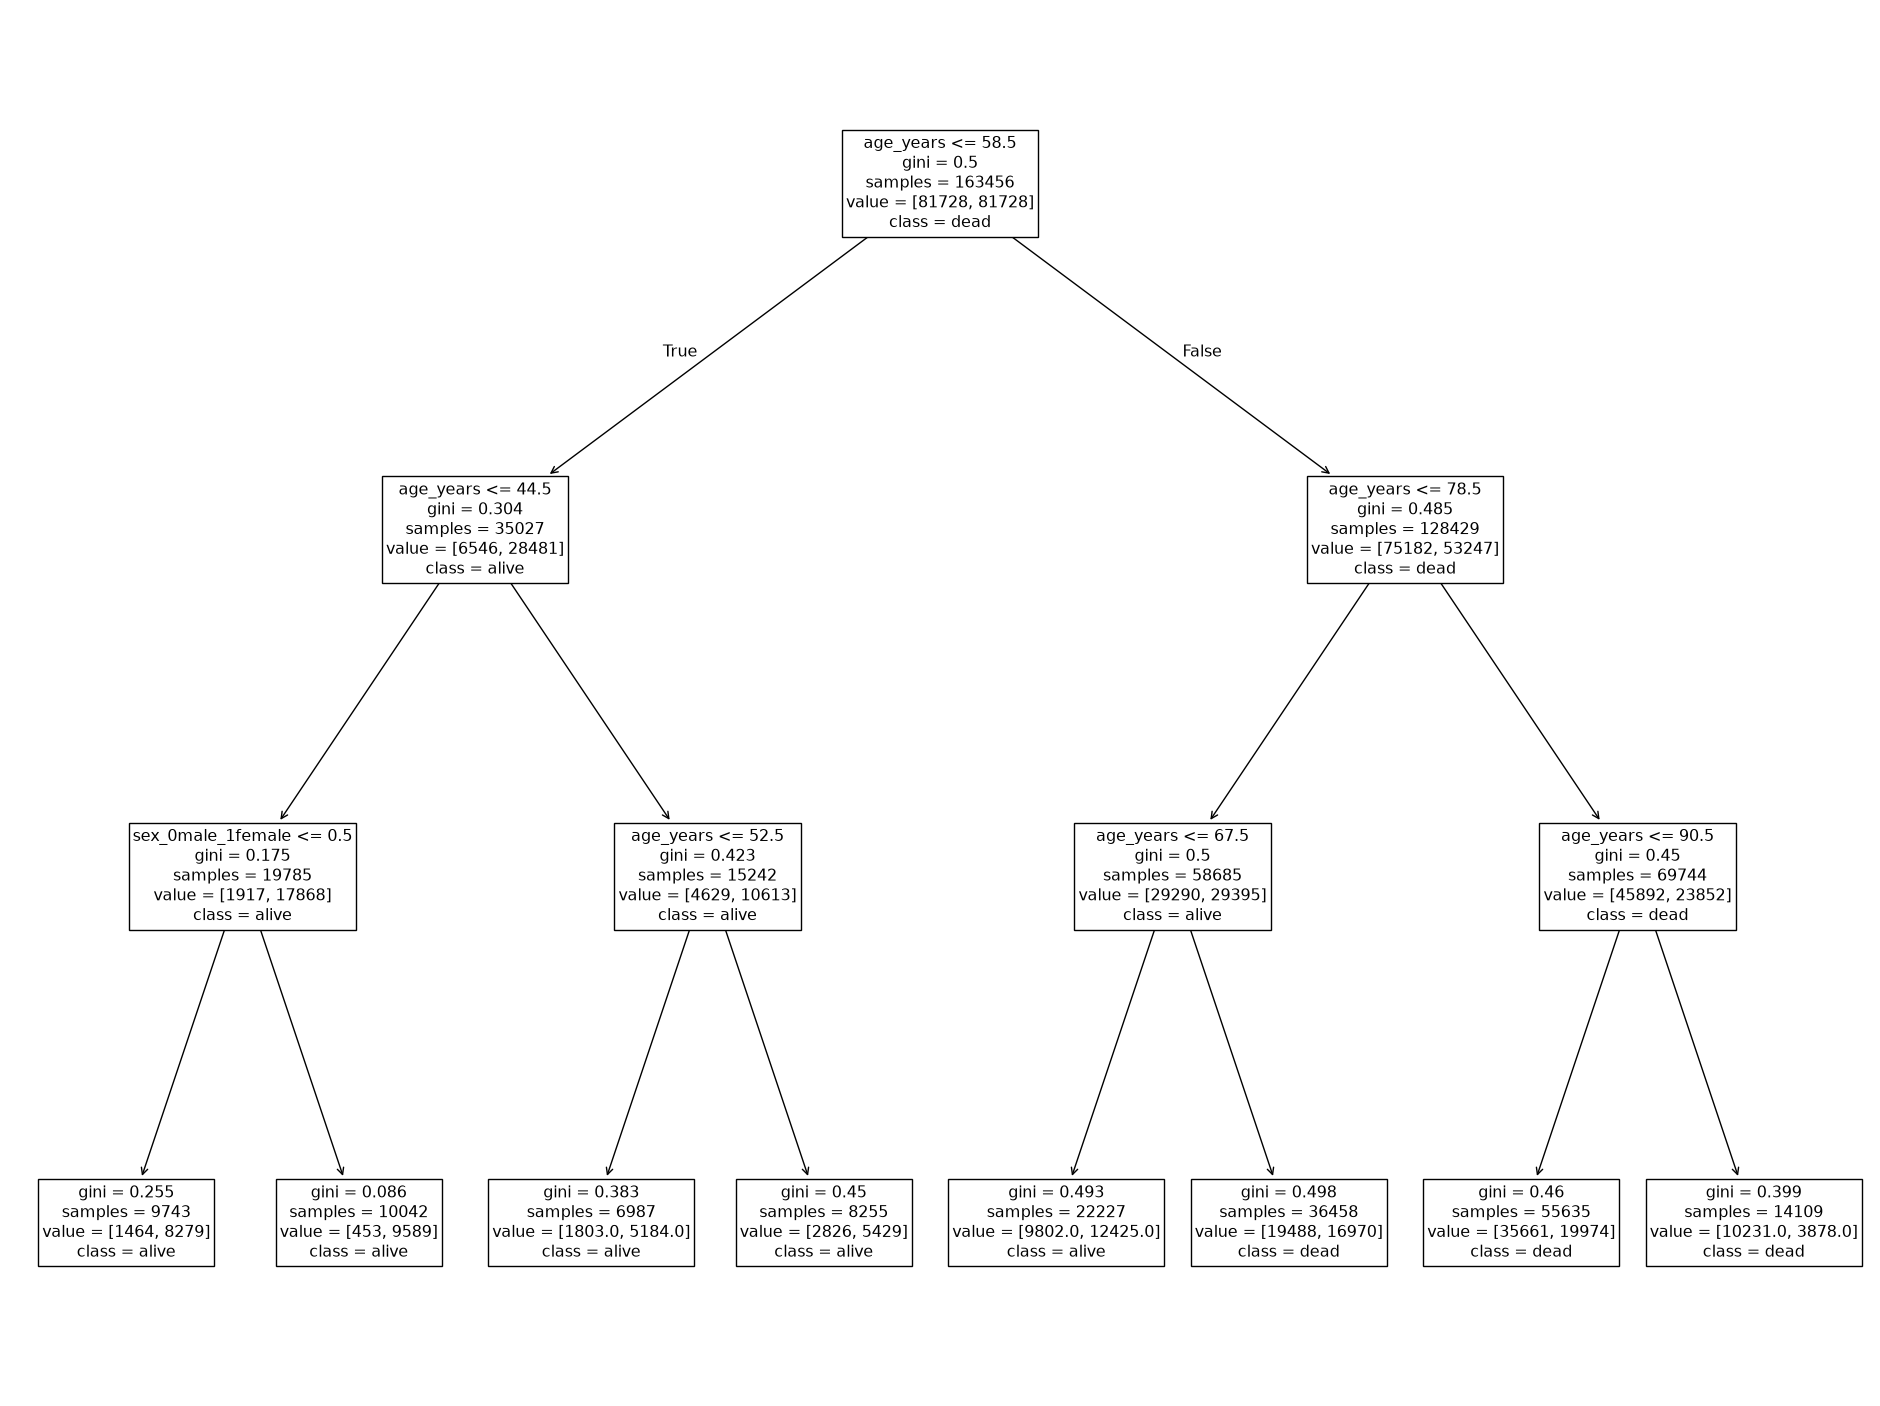

In [16]:
plt.figure(figsize=(24,18))

tree.plot_tree(clf_tuned,feature_names=X_var_names, class_names=['dead', 'alive'])
plt.savefig('visuals/tuned_decision_tree.png',facecolor='white',bbox_inches="tight")
plt.show()

##### Evaluate performance

Precision (dead) = 0.616
Recall (dead) = 0.8
F1 (dead) = 0.696

              precision    recall  f1-score   support

        dead       0.62      0.80      0.70     81728
       alive       0.71      0.50      0.59     81728

    accuracy                           0.65    163456
   macro avg       0.67      0.65      0.64    163456
weighted avg       0.67      0.65      0.64    163456



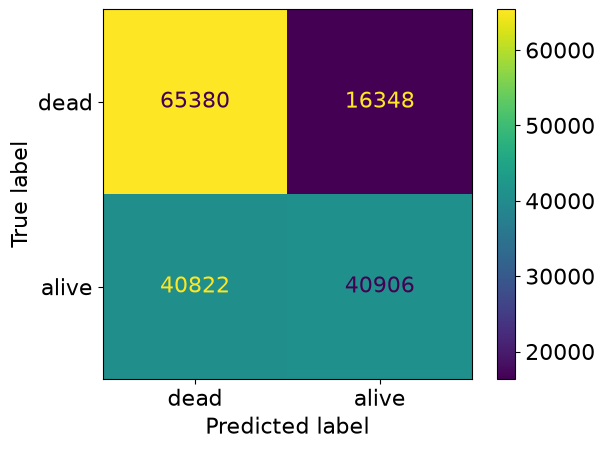

In [17]:
evaluateModel(clf_tuned, X_train, y_train)
plt.savefig('visuals/tuned_decision_tree_training_performance.png',facecolor='white',bbox_inches="tight")

Precision (dead) = 0.114
Recall (dead) = 0.78
F1 (dead) = 0.199

              precision    recall  f1-score   support

        dead       0.11      0.78      0.20      1670
       alive       0.97      0.50      0.66     20371

    accuracy                           0.53     22041
   macro avg       0.54      0.64      0.43     22041
weighted avg       0.90      0.53      0.63     22041



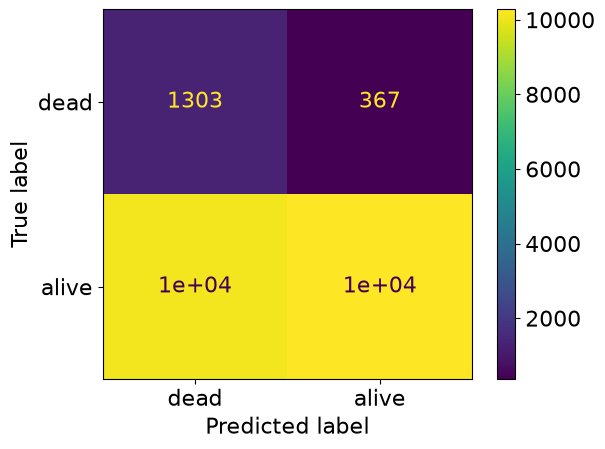

In [18]:
evaluateModel(clf_tuned, X_test, y_test)
plt.savefig('visuals/tuned_decision_tree_testing_performance.png',facecolor='white',bbox_inches="tight")

### Leakage comparison (same real, untouched test set for both)

`X_test`/`y_test` above are the real, never-resampled test patients (split before any SMOTE). To measure the effect of the leakage bug in isolation, we train two versions of the fully-grown tree — one on a train set built the buggy way (SMOTE on the full data, then split) and one on the correct train set (`X_train`/`y_train` above, split then SMOTE) — and evaluate **both on this same real test set**.

In [19]:
# leaky pipeline: SMOTE on the whole dataset, then split (same bug as the original notebook)
X_res_leak, y_res_leak = SMOTE().fit_resample(X, y)
X_train_leak, _, y_train_leak, _ = train_test_split(X_res_leak, y_res_leak, test_size=0.2, random_state=0)

clf_leak = tree.DecisionTreeClassifier(random_state=0)
clf_leak = clf_leak.fit(X_train_leak, y_train_leak)

clf_correct = tree.DecisionTreeClassifier(random_state=0)
clf_correct = clf_correct.fit(X_train, y_train)

**Leaky model, evaluated on the real test set:**

Precision (dead) = 0.121
Recall (dead) = 0.766
F1 (dead) = 0.21

              precision    recall  f1-score   support

        dead       0.12      0.77      0.21      1670
       alive       0.97      0.55      0.70     20371

    accuracy                           0.56     22041
   macro avg       0.54      0.66      0.45     22041
weighted avg       0.90      0.56      0.66     22041



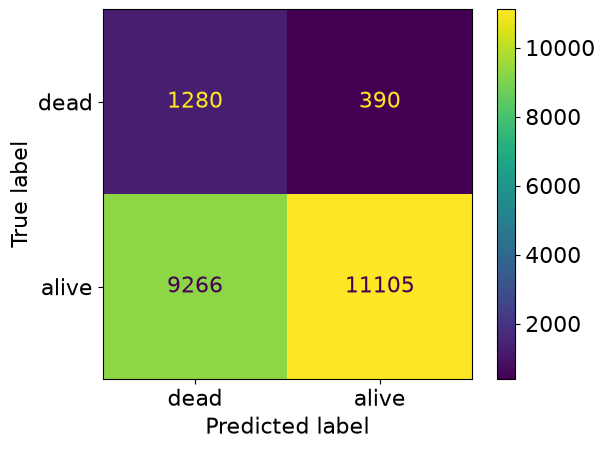

In [20]:
evaluateModel(clf_leak, X_test, y_test)
plt.savefig('visuals/leak_vs_correct_leak_on_real_test.png',facecolor='white',bbox_inches="tight")

**Correct model, evaluated on the same real test set:**

Precision (dead) = 0.113
Recall (dead) = 0.769
F1 (dead) = 0.197

              precision    recall  f1-score   support

        dead       0.11      0.77      0.20      1670
       alive       0.96      0.51      0.66     20371

    accuracy                           0.53     22041
   macro avg       0.54      0.64      0.43     22041
weighted avg       0.90      0.53      0.63     22041



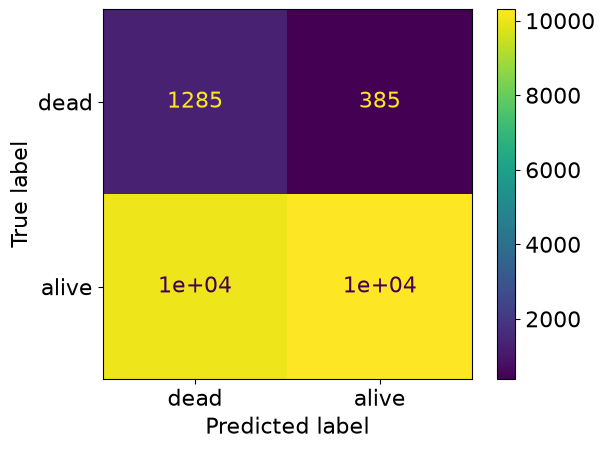

In [21]:
evaluateModel(clf_correct, X_test, y_test)
plt.savefig('visuals/leak_vs_correct_correct_on_real_test.png',facecolor='white',bbox_inches="tight")